# 03 - Feature Engineering: House Price Prediction

Based on the EDA findings:
- `SalePrice` is right-skewed -> apply a log transform.
- A few `GrLivArea` outliers (large area, low price) distort linear models.
- `GarageCars`/`GarageArea` and `TotalBsmtSF`/`1stFlrSF` are highly correlated (multicollinearity).
- Categorical columns need encoding before modeling.

Goal: produce a model-ready dataset saved to `data/processed/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
df = pd.read_csv('../data/processed/train_clean.csv')
df.shape

(1460, 81)

## 1. Remove outliers

Two houses have a very large `GrLivArea` (> 4000 sq ft) but a low `SalePrice`. These are known outliers in this dataset and can mislead linear models.

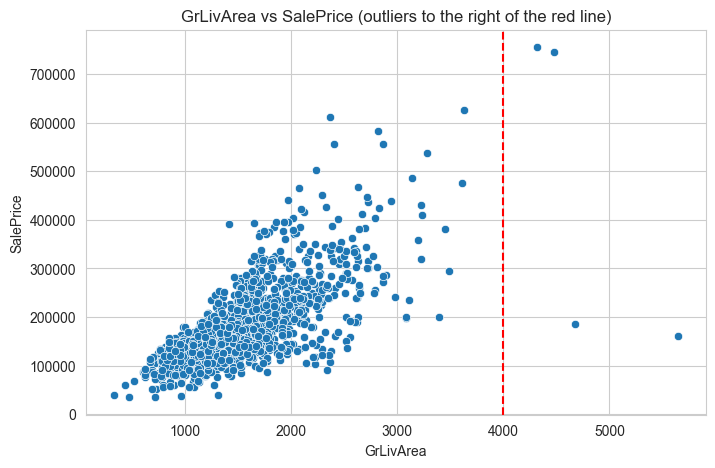

In [3]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'])
plt.axvline(4000, color='red', linestyle='--')
plt.title('GrLivArea vs SalePrice (outliers to the right of the red line)')
plt.show()

In [4]:
before = df.shape[0]
df = df[df['GrLivArea'] < 4000].reset_index(drop=True)
after = df.shape[0]
print(f'Removed {before - after} outlier rows')

Removed 4 outlier rows


## 2. Log-transform the target

`SalePrice` is right-skewed. Modeling `log(SalePrice + 1)` instead makes the target closer to a normal distribution, which helps linear models and evaluation metrics (RMSE becomes less sensitive to a few very expensive houses).

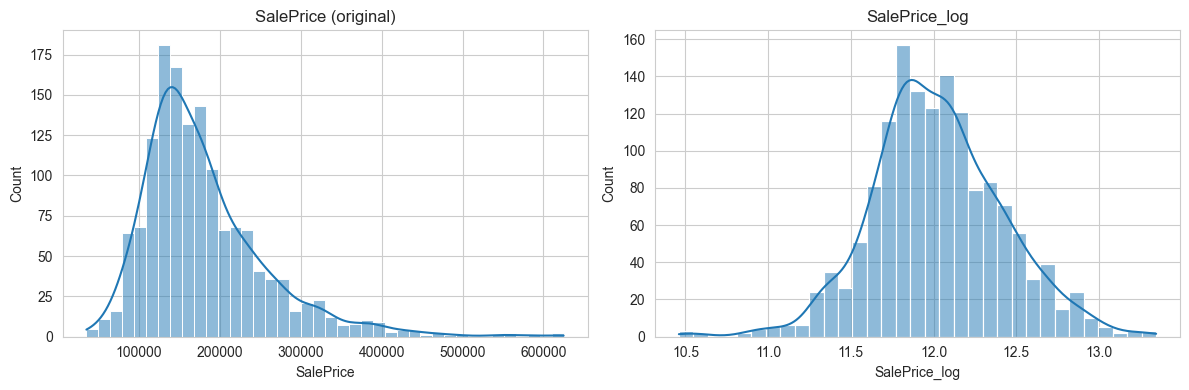

In [5]:
df['SalePrice_log'] = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('SalePrice (original)')
sns.histplot(df['SalePrice_log'], kde=True, ax=axes[1])
axes[1].set_title('SalePrice_log')
plt.tight_layout()
plt.show()

## 3. Create new features

Combining related columns into a few strong features instead of many redundant ones.

In [6]:
# Total living space across basement + both floors
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

# House age at time of sale, and years since last remodel
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']

# Total bathrooms (half baths count as 0.5)
df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                    df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])

# Simple flags
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
df['Has2ndFloor'] = (df['2ndFlrSF'] > 0).astype(int)

df[['TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBath',
    'HasPool', 'HasGarage', 'HasFireplace', 'Has2ndFloor']].head()

,TotalSF,HouseAge,YearsSinceRemodel,TotalBath,HasPool,HasGarage,HasFireplace,Has2ndFloor
0,2566,5,5,3.5,0,1,0,1
1,2524,31,31,2.5,0,1,1,0
2,2706,7,6,3.5,0,1,1,1
3,2473,91,36,2.0,0,1,1,1
4,3343,8,8,3.5,0,1,1,1


## 4. Drop redundant / multicollinear columns

From the correlation heatmap:
- `GarageArea` duplicates `GarageCars` (corr 0.88) -> keep `GarageCars`.
- `TotalBsmtSF` and `1stFlrSF` are now folded into `TotalSF` -> drop both.
- `2ndFlrSF` is also folded into `TotalSF` -> drop it.
- `YearBuilt`/`YearRemodAdd`/`YrSold` are now captured by `HouseAge`/`YearsSinceRemodel` -> drop the raw years.
- `Id` carries no predictive information.

In [7]:
drop_cols = ['Id', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
             'YearBuilt', 'YearRemodAdd', 'YrSold', 'SalePrice']
df = df.drop(columns=drop_cols)
df.shape

(1456, 81)

## 5. Encode categorical columns

Models need numbers, not text. We use one-hot encoding (`pd.get_dummies`) for all remaining categorical (object) columns.

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'{len(cat_cols)} categorical columns to encode')

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.shape

43 categorical columns to encode


C:\Users\mna12\AppData\Local\Temp\ipykernel_16816\3981338455.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


(1456, 245)

## 6. Save the model-ready dataset

In [9]:
df.to_csv('../data/processed/train_features.csv', index=False)
df.shape

(1456, 245)